In [1]:
import csv
import re
import math
from collections import Counter, defaultdict
import random

try:
    from nltk.corpus import stopwords as nltk_sw
    AZ_STOPWORDS = set(nltk_sw.words('azerbaijani'))
except Exception:
    AZ_STOPWORDS = {
        "bir", "bu", "da", "də", "və", "ki", "o", "ilə", "üçün", "artıq",
        "çox", "daha", "belə", "lakin", "amma", "bütün", "heç", "ancaq",
        "isə", "ona", "onun", "onlar", "biz", "siz", "mən", "sən", "hər",
        "nə", "necə", "harada", "hansı", "nəyin", "nədən", "özü", "özünü",
    }


AZ_LOWER_MAP = str.maketrans("ƏIÖÜĞŞÇİ", "əıöüğşçi")

# Data Preprocessing 

In [2]:
# Tokenizing text
def tokenize(text):
    text = re.sub(r"<.*?>", " ", text)
    text = text.translate(AZ_LOWER_MAP).lower()
    # Keep standard Latin letters + Azerbaijani special letters
    text = re.sub(r"[^a-zəıöüğşç\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in AZ_STOPWORDS and len(t) > 1]
    return tokens

# Reading input CSV file and tokenizing reviews
def load_data(path):
    data = []
    with open(path, newline='', encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader, start=2):
            raw_label = (row.get("sentiment") or "").strip()
            raw_text  = (row.get("review")    or "").strip()

            if not raw_label:
                print(f"  [Warning] Row {i}: missing 'sentiment' value – skipped.")
                continue
            if not raw_text:
                print(f"  [Warning] Row {i}: empty 'review' text – skipped.")
                continue
            if raw_label not in ("0", "1"):
                print(f"  [Warning] Row {i}: unexpected label '{raw_label}' – skipped.")
                continue

            tokens = tokenize(raw_text)
            label  = int(raw_label)
            data.append((tokens, label))

    print(f"  Loaded {len(data)} valid rows.")
    return data

In [3]:
POS_WORDS = {
    # good, great, excellent, wonderful, beautiful, nice, perfect
    "yaxşı", "əla", "gözəl", "mükəmməl", "möhtəşəm", "əzəmətli",
    # enjoyable, wonderful, magnificent, interesting, funny
    "maraqlı", "əyləncəli", "zövqlü", "heyrətləndirici", "qəşəng",
    # loved, recommended, liked, happy, pleased
    "sevdim", "bəyəndim", "xoşladım", "tövsiyə", "məmnun",
    # brilliant, outstanding, superb, talented, impressive
    "istedadlı", "parlaq", "uğurlu", "təsirli", "fövqəladə",
    # fun, cheerful, spectacular, fantastic
    "əyləncəli", "şən", "möcüzəli", "fantastik", "sensasion",
}
NEG_WORDS = {
    # bad, terrible, awful, boring, poor
    "pis", "dəhşətli", "zəif", "darıxdırıcı", "acınacaqlı",
    # waste, disgusting, horrible, disappointed, worst
    "iyrənc", "dözülməz", "məyus", "ən pis", "boş",
    # stupid, ridiculous, pathetic, annoying, dull
    "axmaq", "gülünc", "yazıq", "sinir", "cansıxıcı",
    # failure, nonsense, unbearable, weak, mediocre
    "uğursuz", "mənasız", "dözülməz", "orta", "antitalent",
    # hated, not recommended, disliked, regret
    "xoşlamadım", "sevmədim", "peşman", "tövsiyə etmirəm", "ikrah",
}

AZ_SUFFIXES = [
    # Longest first to apply most specific rule first
    "lərdən", "lardan", "lərə", "lara", "ləri", "ları",
    "lərin", "ların", "lərə", "lara", "lərdə", "larda",
    "lərdə", "larda", "ların", "lerin",
    "dən", "dan", "dır", "dir", "dur", "dür",
    "nın", "nin", "nun", "nün",
    "nda", "ndə", "nda", "ndən",
    "lar", "lər", "ın", "in", "un", "ün",
    "da", "də", "ə", "a", "ı", "i",
    "ır", "ir", "ur", "ür",
    "mış", "miş", "muş", "müş",
    "acaq", "əcək", "malı", "məli",
    "sı", "si", "su", "sü",
]

In [4]:
def lexicon_features(tokens):
    pos = sum(1 for t in tokens if t in POS_WORDS)
    neg = sum(1 for t in tokens if t in NEG_WORDS)
    return pos, neg

In [5]:
# Keeping only the stem of the word by removing common Azerbaijani suffixes
def az_stem(word):
    for suffix in AZ_SUFFIXES:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[: len(word) - len(suffix)]
    return word

In [6]:
# Building vocabulary from training data
def build_vocab(train_data, min_freq=2):
    freq = Counter()
    for tokens, _ in train_data:
        freq.update(az_stem(t) for t in tokens)
    return {w for w, c in freq.items() if c >= min_freq}

# BoW and Lexicon Features Functions

In [7]:
# Extracting features for a review based on the vocabulary and lexicon counts
def bow_features(tokens, vocab, binary=False):
    stemmed = [az_stem(t) for t in tokens]
    counts = Counter(stemmed)
    if binary:
        return {w: 1 for w in counts if w in vocab}
    return {w: counts[w] for w in counts if w in vocab}

def make_features(tokens, vocab, binary=False):
    feats = bow_features(tokens, vocab, binary)
    pos, neg = lexicon_features(tokens)
    feats["LEX_POS"] = pos
    feats["LEX_NEG"] = neg
    return feats

In [8]:
# Splitting data into train/test sets
def split(data, ratio=0.8):
    data = list(data)
    random.shuffle(data)
    k = int(len(data) * ratio)
    return data[:k], data[k:]

# Naive Bayes

In [9]:
class NaiveBayes:
    def train(self, data):
        self.class_counts = Counter()
        self.word_counts  = defaultdict(Counter)
        self.total_words  = Counter()

        for feats, y in data:
            self.class_counts[y] += 1
            for w, c in feats.items():
                self.word_counts[y][w] += c
                self.total_words[y]    += c

        self.vocab_size = len({w for wc in self.word_counts.values() for w in wc})

    def predict(self, feats):
        scores = {}
        for y in self.class_counts:
            total = sum(self.class_counts.values())
            logp  = math.log(self.class_counts[y] / total)
            for w, c in feats.items():
                num   = self.word_counts[y][w] + 1
                den   = self.total_words[y]    + self.vocab_size
                logp += c * math.log(num / den)
            scores[y] = logp
        return max(scores, key=scores.get)

# Logistic Regression

In [10]:
class LogisticRegression:
    def __init__(self, lr=0.1, epochs=10):
        self.lr     = lr
        self.epochs = epochs
        self.w      = defaultdict(float)
        self.bias   = 0.0   # bias term added for better calibration

    def sigmoid(self, z):
        if z >= 0:
            return 1 / (1 + math.exp(-z))
        ez = math.exp(z)
        return ez / (1 + ez)

    def train(self, data):
        for _ in range(self.epochs):
            for feats, y in data:
                z = sum(self.w[f] * v for f, v in feats.items()) + self.bias
                p = self.sigmoid(z)
                err = y - p
                for f, v in feats.items():
                    self.w[f] += self.lr * err * v
                self.bias += self.lr * err   # update bias

    def predict(self, feats):
        z = sum(self.w[f] * v for f, v in feats.items()) + self.bias
        return 1 if self.sigmoid(z) >= 0.5 else 0

In [11]:
# Getting predictions for a dataset
def get_predictions(model, data):
    return [model.predict(f) for f, _ in data]

# Confusion matrix: TP, TN, FP, FN counts
def confusion_matrix(preds, gold):
    tp = sum(p == 1 and g == 1 for p, g in zip(preds, gold))
    tn = sum(p == 0 and g == 0 for p, g in zip(preds, gold))
    fp = sum(p == 1 and g == 0 for p, g in zip(preds, gold))
    fn = sum(p == 0 and g == 1 for p, g in zip(preds, gold))
    return tp, tn, fp, fn

# Precision, Recall, F1-score calculation
def precision_recall_f1(preds, gold):
    tp, tn, fp, fn = confusion_matrix(preds, gold)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    return precision, recall, f1

# Formatted printing of evaluation metrics
def print_metrics(name, preds, gold):
    acc        = sum(p == g for p, g in zip(preds, gold)) / len(gold)
    p, r, f1   = precision_recall_f1(preds, gold)
    tp, tn, fp, fn = confusion_matrix(preds, gold)
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {p:.4f}")
    print(f"  Recall    : {r:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  Confusion matrix  (1=good / 0=bad):")
    print(f"            Pred+   Pred-")
    print(f"  Actual+   {tp:5d}   {fn:5d}   (TP / FN)")
    print(f"  Actual-   {fp:5d}   {tn:5d}   (FP / TN)")

# McNemar Test

In [12]:
def mcnemar(pred1, pred2, gold, label1="A", label2="B"):
    b = c = 0
    for p1, p2, y in zip(pred1, pred2, gold):
        if p1 == y and p2 != y:
            b += 1
        elif p1 != y and p2 == y:
            c += 1

    if (b + c) == 0:
        print(f"\nMcNemar ({label1} vs {label2}): b+c=0, models identical – no test possible.")
        return 0.0

    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    sig  = chi2 > 3.841

    print(f"\nMcNemar's test - {label1} vs {label2}:")
    print(f"  b (only {label1} correct) = {b}")
    print(f"  c (only {label2} correct) = {c}")
    print(f"  chi² = {chi2:.4f}")
    print(f"  {'Significant difference (p < 0.05)' if sig else 'No significant difference (p ≥ 0.05)'}")
    return chi2

# Sentiment Predictions

In [13]:
def predict_text(text, vocab, nb, bnb, lr):
    tokens    = tokenize(text)
    feats_nb  = make_features(tokens, vocab, binary=False)
    feats_bnb = make_features(tokens, vocab, binary=True)
    label     = {1: "positive", 0: "negative"}

    return {
        "Naive Bayes"        : label[nb.predict(feats_nb)],
        "Binary Naive Bayes" : label[bnb.predict(feats_bnb)],
        "Logistic Regression": label[lr.predict(feats_nb)],
    }


# Sentiment Model Training

In [14]:
print("Loading data…")

data = load_data("../data/csv/dataset.csv")
train_raw, test_raw = split(data, ratio=0.8)
print(f"Train: {len(train_raw)}  |  Test: {len(test_raw)}")

# Build vocab from training data (stems applied)
vocab = build_vocab(train_raw, min_freq=2)
print(f"Vocabulary size (stemmed): {len(vocab)}")

# Build feature sets
train     = [(make_features(t, vocab, binary=False), y) for t, y in train_raw]
test      = [(make_features(t, vocab, binary=False), y) for t, y in test_raw]
train_bin = [(make_features(t, vocab, binary=True),  y) for t, y in train_raw]
test_bin  = [(make_features(t, vocab, binary=True),  y) for t, y in test_raw]

# Train models
print("\nTraining models…")
nb  = NaiveBayes();          nb.train(train)
bnb = NaiveBayes();          bnb.train(train_bin)
lr  = LogisticRegression();  lr.train(train)

# Generate predictions
gold     = [y for _, y in test]
pred_nb  = get_predictions(nb,  test)
pred_bnb = get_predictions(bnb, test_bin)
pred_lr  = get_predictions(lr,  test)

# Print full evaluation
print("\n" + "═"*45)
print("  EVALUATION RESULTS  (1=positive, 0=negative)")
print("═"*45)
print_metrics("Naive Bayes (count BoW)",           pred_nb,  gold)
print_metrics("Binary Naive Bayes",                pred_bnb, gold)
print_metrics("Logistic Regression (count BoW)",   pred_lr,  gold)

# Statistical significance tests
print("\n" + "═"*45)
print("  STATISTICAL SIGNIFICANCE (McNemar's Test)")
print("═"*45)
mcnemar(pred_nb,  pred_lr,  gold, label1="NB",  label2="LR")
mcnemar(pred_bnb, pred_lr,  gold, label1="BNB", label2="LR")
mcnemar(pred_nb,  pred_bnb, gold, label1="NB",  label2="BNB")

# Summary
accs = {
    "Naive Bayes"        : sum(p == g for p, g in zip(pred_nb,  gold)) / len(gold),
    "Binary Naive Bayes" : sum(p == g for p, g in zip(pred_bnb, gold)) / len(gold),
    "Logistic Regression": sum(p == g for p, g in zip(pred_lr,  gold)) / len(gold),
}
best = max(accs, key=accs.get)
print(f"\n{'═'*45}")
print(f"  SUMMARY")
print(f"{'═'*45}")
for name, acc in accs.items():
    marker = " ← best" if name == best else ""
    print(f"  {name:<28} {acc:.4f}{marker}")

# Sample prediction in Azerbaijani
print("\n" + "═"*45)
print("  SAMPLE PREDICTION (Azerbaijani)")
print("═"*45)
sample = "Bu film həqiqətən çox yaxşı idi, möhtəşəm rejissor işi və gözəl aktyorlar."
print(f"  Mətn : \"{sample}\"")
results = predict_text(sample, vocab, nb, bnb, lr)
for model, label in results.items():
    print(f"  {model:<28} → {label}")

Loading data…
  [Warning] Row 24911: missing 'sentiment' value – skipped.
  [Warning] Row 24912: missing 'sentiment' value – skipped.
  [Warning] Row 24913: missing 'sentiment' value – skipped.
  [Warning] Row 24914: missing 'sentiment' value – skipped.
  [Warning] Row 24915: missing 'sentiment' value – skipped.
  [Warning] Row 24916: missing 'sentiment' value – skipped.
  [Warning] Row 24917: missing 'sentiment' value – skipped.
  [Warning] Row 24918: missing 'sentiment' value – skipped.
  [Warning] Row 24919: missing 'sentiment' value – skipped.
  [Warning] Row 24921: missing 'sentiment' value – skipped.
  [Warning] Row 24922: missing 'sentiment' value – skipped.
  [Warning] Row 24923: missing 'sentiment' value – skipped.
  [Warning] Row 24924: missing 'sentiment' value – skipped.
  [Warning] Row 24925: missing 'sentiment' value – skipped.
  [Warning] Row 24926: missing 'sentiment' value – skipped.
  [Warning] Row 24927: missing 'sentiment' value – skipped.
  [Warning] Row 24928: mis

In [15]:
sample = "Bu film həqiqətən çox yaxşı idi, möhtəşəm rejissor işi və gözəl aktyorlar."
print(f"  Mətn : \"{sample}\"")
results = predict_text(sample, vocab, nb, bnb, lr)
for model, label in results.items():
    print(f"  {model:<28} → {label}")

  Mətn : "Bu film həqiqətən çox yaxşı idi, möhtəşəm rejissor işi və gözəl aktyorlar."
  Naive Bayes                  → positive
  Binary Naive Bayes           → positive
  Logistic Regression          → positive


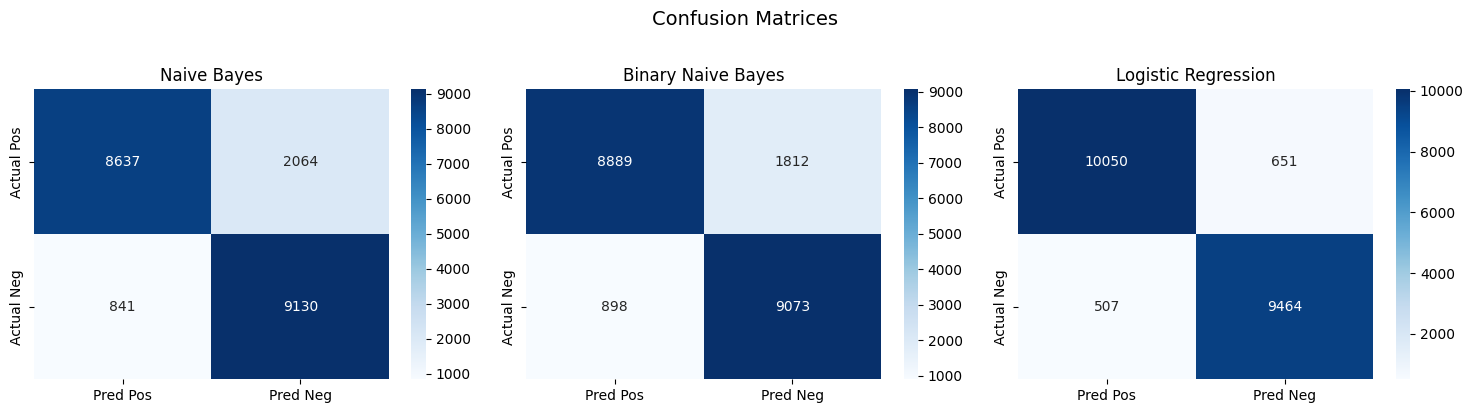

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_all_confusion_matrices(pred_nb, pred_bnb, pred_lr, gold):
    models = [
        ("Naive Bayes",         pred_nb),
        ("Binary Naive Bayes",  pred_bnb),
        ("Logistic Regression", pred_lr),
    ]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, (name, preds) in zip(axes, models):
        tp, tn, fp, fn = confusion_matrix(preds, gold)
        matrix = [[tp, fn], [fp, tn]]
        
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Pred Pos", "Pred Neg"],
            yticklabels=["Actual Pos", "Actual Neg"],
            ax=ax
        )
        ax.set_title(name)
    
    plt.suptitle("Confusion Matrices", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_confusion_matrices(pred_nb, pred_bnb, pred_lr, gold)

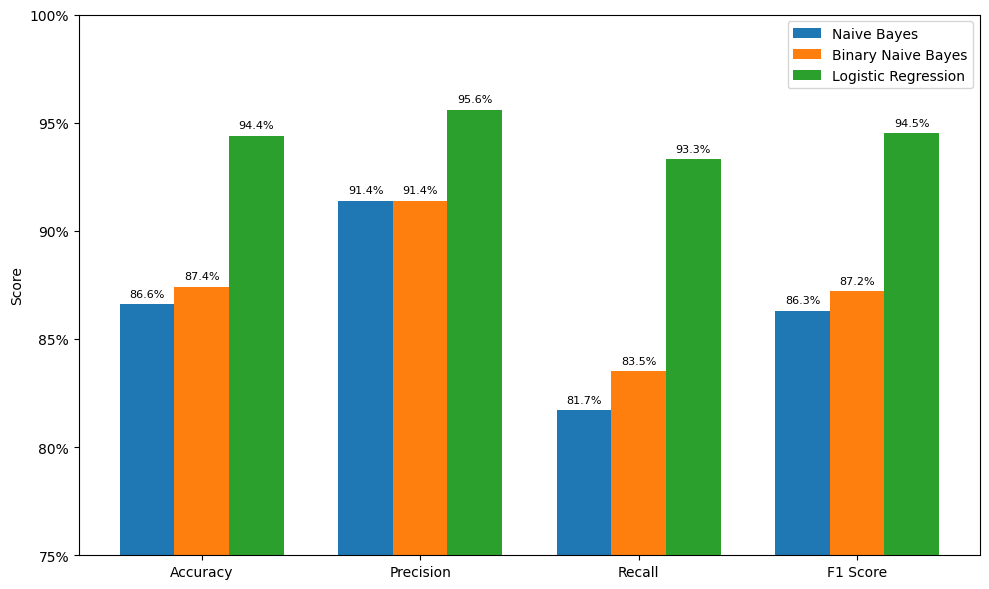

In [18]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Naive Bayes", "Binary Naive Bayes", "Logistic Regression"]
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

scores = [
    [0.866, 0.914, 0.817, 0.863],  # Naive Bayes
    [0.874, 0.914, 0.835, 0.872],  # Binary Naive Bayes
    [0.944, 0.956, 0.933, 0.945],  # Logistic Regression
]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, (model, score) in enumerate(zip(models, scores)):
    bars = ax.bar(x + i * width, score, width, label=model)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.1%}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

ax.set_ylim(0.75, 1.0)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

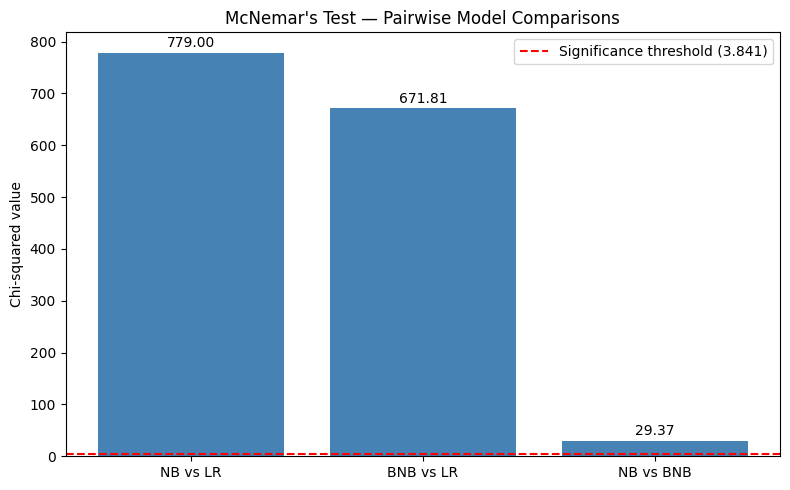

In [19]:
import matplotlib.pyplot as plt

comparisons = ["NB vs LR", "BNB vs LR", "NB vs BNB"]
chi2_values = [779.00, 671.81, 29.37]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(comparisons, chi2_values, color=["steelblue", "steelblue", "steelblue"])
ax.axhline(y=3.841, color="red", linestyle="--", label="Significance threshold (3.841)")
ax.set_ylabel("Chi-squared value")
ax.set_title("McNemar's Test — Pairwise Model Comparisons")
ax.legend()

for bar, val in zip(bars, chi2_values):
    ax.annotate(f"{val:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center", fontsize=10)

plt.tight_layout()
plt.show()